In [ ]:
# # Install required packages
# !pip install confluent-kafka pandas scikit-learn torch tqdm matplotlib

# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, accuracy_score
# from tqdm import tqdm
# import matplotlib.pyplot as plt
# import json
# import time
# from confluent_kafka import Producer, Consumer
# from sklearn.model_selection import train_test_split

# # =============================================
# # Part 1: Enhanced Model Training with Validation
# # =============================================

# # Load and clean dataset
# data = pd.read_csv('/content/water_potability.csv')  # Update path as needed
# data = data.dropna()

# # Features and labels
# X = data.drop('Potability', axis=1).values
# y = data['Potability'].values

# # Normalize with Z-score
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# # Convert to torch tensors
# X = torch.tensor(X, dtype=torch.float32)
# y = torch.tensor(y, dtype=torch.long)

# # Define the neural network
# class PotabilityNN(nn.Module):
#     def __init__(self):
#         super(PotabilityNN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(9, 64),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Linear(32, 2)
#         )

#     def forward(self, x):
#         return self.model(x)

# # Train/test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y)

# # Convert to DataLoader for batch processing
# from torch.utils.data import TensorDataset, DataLoader
# train_dataset = TensorDataset(X_train, y_train)
# test_dataset = TensorDataset(X_test, y_test)

# batch_size = 32
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size)

# # Initialize model, loss, optimizer
# model = PotabilityNN()
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# # Training parameters
# n_epochs = 100
# train_loss_history = []
# val_loss_history = []
# train_acc_history = []
# val_acc_history = []

# print("Starting training...\n")
# for epoch in range(n_epochs):
#     # Training phase
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for inputs, labels in train_loader:
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

#     train_loss = running_loss / len(train_loader)
#     train_acc = correct / total
#     train_loss_history.append(train_loss)
#     train_acc_history.append(train_acc)

#     # Validation phase
#     model.eval()
#     val_running_loss = 0.0
#     val_correct = 0
#     val_total = 0

#     with torch.no_grad():
#         for inputs, labels in test_loader:
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)

#             val_running_loss += loss.item()
#             _, predicted = torch.max(outputs.data, 1)
#             val_total += labels.size(0)
#             val_correct += (predicted == labels).sum().item()

#     val_loss = val_running_loss / len(test_loader)
#     val_acc = val_correct / val_total
#     val_loss_history.append(val_loss)
#     val_acc_history.append(val_acc)

#     # Print epoch statistics
#     print(f'Epoch {epoch+1}/{n_epochs} - '
#           f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - '
#           f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

# # Save the trained model
# torch.save(model.state_dict(), 'water_potability_model.pt')
# print("\nModel trained and saved successfully!")

# # =============================================
# # Part 2: Enhanced Training Visualization
# # =============================================

# plt.figure(figsize=(12, 5))

# # Plot training and validation loss
# plt.subplot(1, 2, 1)
# plt.plot(train_loss_history, label='Train Loss')
# plt.plot(val_loss_history, label='Validation Loss')
# plt.title('Training and Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)

# # Plot training and validation accuracy
# plt.subplot(1, 2, 2)
# plt.plot(train_acc_history, label='Train Accuracy')
# plt.plot(val_acc_history, label='Validation Accuracy')
# plt.title('Training and Validation Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # =============================================
# # Part 3: Kafka Simulation and Stream Processing
# # =============================================

# # (Rest of the Kafka simulation code remains the same as previous version)
# # ...

# # When plotting predictions, use improved visualization
# if not results_df.empty:
#     plt.figure(figsize=(14, 6))

#     # Plot prediction distribution
#     plt.subplot(1, 2, 1)
#     results_df['prediction'].value_counts().sort_index().plot(
#         kind='bar', color=['red', 'green'], edgecolor='black')
#     plt.title('Water Potability Predictions Distribution', pad=20)
#     plt.xlabel('Potability (0=Not Potable, 1=Potable)')
#     plt.ylabel('Count')
#     plt.xticks(rotation=0)

#     # Plot probability distribution
#     plt.subplot(1, 2, 2)
#     plt.hist(results_df['probability'], bins=20, color='blue', edgecolor='black')
#     plt.title('Prediction Confidence Distribution', pad=20)
#     plt.xlabel('Prediction Probability')
#     plt.ylabel('Count')

#     plt.tight_layout()
#     plt.show()

Starting training...

Epoch 1/50: Train Loss: 0.6887, Acc: 0.5572 | Val Loss: 0.6791, Acc: 0.5970
Epoch 2/50: Train Loss: 0.6718, Acc: 0.5962 | Val Loss: 0.6741, Acc: 0.5970
Epoch 3/50: Train Loss: 0.6624, Acc: 0.6086 | Val Loss: 0.6684, Acc: 0.6070
Epoch 4/50: Train Loss: 0.6545, Acc: 0.6202 | Val Loss: 0.6586, Acc: 0.6194
Epoch 5/50: Train Loss: 0.6383, Acc: 0.6625 | Val Loss: 0.6487, Acc: 0.6567
Epoch 6/50: Train Loss: 0.6266, Acc: 0.6534 | Val Loss: 0.6449, Acc: 0.6642
Epoch 7/50: Train Loss: 0.6064, Acc: 0.6816 | Val Loss: 0.6394, Acc: 0.6542
Epoch 8/50: Train Loss: 0.6152, Acc: 0.6517 | Val Loss: 0.6283, Acc: 0.6716
Epoch 9/50: Train Loss: 0.5961, Acc: 0.6791 | Val Loss: 0.6270, Acc: 0.6741
Epoch 10/50: Train Loss: 0.5922, Acc: 0.6924 | Val Loss: 0.6304, Acc: 0.6816
Epoch 11/50: Train Loss: 0.5781, Acc: 0.6915 | Val Loss: 0.6306, Acc: 0.6766
Epoch 12/50: Train Loss: 0.5829, Acc: 0.6932 | Val Loss: 0.6280, Acc: 0.6766
Epoch 13/50: Train Loss: 0.5824, Acc: 0.6833 | Val Loss: 0.6251

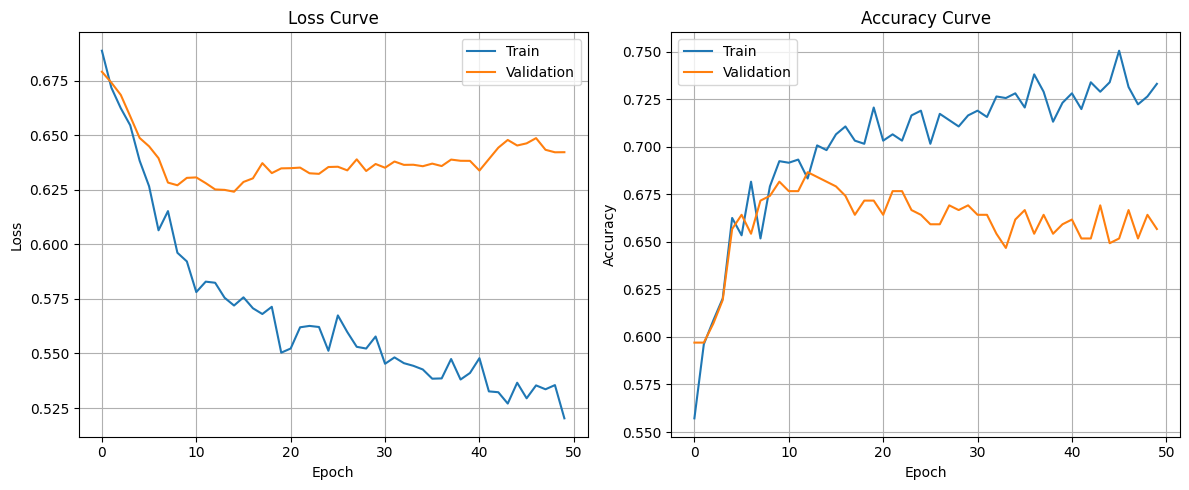


Final Evaluation on Test Set
Test Loss: 0.5878
Test Accuracy: 67.74%

Classification Report:
              precision    recall  f1-score   support

 Not Potable       0.69      0.83      0.75       240
     Potable       0.64      0.45      0.53       163

    accuracy                           0.68       403
   macro avg       0.67      0.64      0.64       403
weighted avg       0.67      0.68      0.66       403



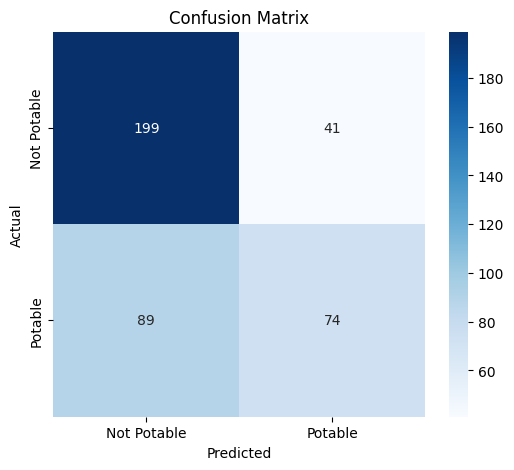

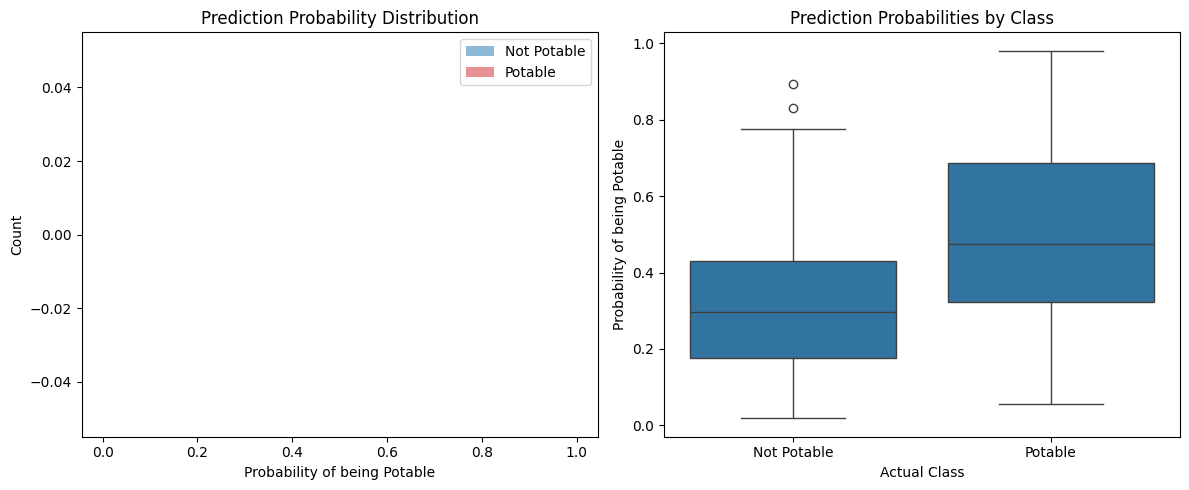

In [ ]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# from sklearn.model_selection import train_test_split
# import matplotlib.pyplot as plt
# import seaborn as sns
# from torch.utils.data import TensorDataset, DataLoader

# # =============================================
# # 1. Data Preparation
# # =============================================

# # Load and clean dataset
# data = pd.read_csv('/content/water_potability.csv')
# data = data.dropna()

# # Features and labels
# X = data.drop('Potability', axis=1).values
# y = data['Potability'].values

# # Normalize with Z-score
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# # Convert to torch tensors
# X = torch.tensor(X, dtype=torch.float32)
# y = torch.tensor(y, dtype=torch.long)

# # Split into train (60%), validation (20%), and test (20%)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y)
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)  # 0.25 x 0.8 = 20%

# # Create DataLoaders
# batch_size = 32
# train_dataset = TensorDataset(X_train, y_train)
# val_dataset = TensorDataset(X_val, y_val)
# test_dataset = TensorDataset(X_test, y_test)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size)
# test_loader = DataLoader(test_dataset, batch_size=batch_size)

# # =============================================
# # 2. Model Definition
# # =============================================

# class WaterPotabilityNN(nn.Module):
#     def __init__(self):
#         super(WaterPotabilityNN, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(9, 64),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Linear(32, 2)
#         )

#     def forward(self, x):
#         return self.model(x)

# model = WaterPotabilityNN()
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# # =============================================
# # 3. Training with Validation
# # =============================================

# n_epochs = 50
# train_loss_history = []
# val_loss_history = []
# train_acc_history = []
# val_acc_history = []

# best_val_acc = 0
# best_model = None

# print("Starting training...\n")
# for epoch in range(n_epochs):
#     # Training phase
#     model.train()
#     train_loss = 0
#     train_correct = 0
#     train_total = 0

#     for inputs, labels in train_loader:
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()
#         _, predicted = torch.max(outputs.data, 1)
#         train_total += labels.size(0)
#         train_correct += (predicted == labels).sum().item()

#     train_loss = train_loss / len(train_loader)
#     train_acc = train_correct / train_total
#     train_loss_history.append(train_loss)
#     train_acc_history.append(train_acc)

#     # Validation phase
#     model.eval()
#     val_loss = 0
#     val_correct = 0
#     val_total = 0

#     with torch.no_grad():
#         for inputs, labels in val_loader:
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)

#             val_loss += loss.item()
#             _, predicted = torch.max(outputs.data, 1)
#             val_total += labels.size(0)
#             val_correct += (predicted == labels).sum().item()

#     val_loss = val_loss / len(val_loader)
#     val_acc = val_correct / val_total
#     val_loss_history.append(val_loss)
#     val_acc_history.append(val_acc)

#     # Save best model
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_model = model.state_dict()

#     print(f'Epoch {epoch+1}/{n_epochs}: '
#           f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
#           f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

# # Save the best model
# torch.save(best_model, 'best_water_potability_model.pt')
# print("\nTraining complete. Best validation accuracy: {:.2f}%".format(best_val_acc * 100))

# # =============================================
# # 4. Training Visualization
# # =============================================

# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.plot(train_loss_history, label='Train')
# plt.plot(val_loss_history, label='Validation')
# plt.title('Loss Curve')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.plot(train_acc_history, label='Train')
# plt.plot(val_acc_history, label='Validation')
# plt.title('Accuracy Curve')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # =============================================
# # 5. Testing on Hold-Out Set
# # =============================================

# # Load best model
# model.load_state_dict(torch.load('best_water_potability_model.pt'))
# model.eval()

# test_loss = 0
# test_correct = 0
# test_total = 0
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)

#         test_loss += loss.item()
#         _, predicted = torch.max(outputs.data, 1)
#         test_total += labels.size(0)
#         test_correct += (predicted == labels).sum().item()

#         all_preds.extend(predicted.numpy())
#         all_labels.extend(labels.numpy())

# test_loss = test_loss / len(test_loader)
# test_acc = test_correct / test_total

# print("\n" + "="*50)
# print("Final Evaluation on Test Set")
# print("="*50)
# print(f"Test Loss: {test_loss:.4f}")
# print(f"Test Accuracy: {test_acc*100:.2f}%")
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=['Not Potable', 'Potable']))

# # Confusion Matrix
# cm = confusion_matrix(all_labels, all_preds)
# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['Not Potable', 'Potable'],
#             yticklabels=['Not Potable', 'Potable'])
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()

# # =============================================
# # 6. Prediction Visualization
# # =============================================

# # Get prediction probabilities
# with torch.no_grad():
#     test_probs = torch.softmax(model(X_test), dim=1)[:, 1].numpy()

# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.hist(test_probs[all_labels == 0], bins=20, alpha=0.5, label='Not Potable')
# plt.hist(test_probs[all_labels == 1], bins=20, alpha=0.5, label='Potable')
# plt.title('Prediction Probability Distribution')
# plt.xlabel('Probability of being Potable')
# plt.ylabel('Count')
# plt.legend()

# plt.subplot(1, 2, 2)
# sns.boxplot(x=all_labels, y=test_probs)
# plt.xticks([0, 1], ['Not Potable', 'Potable'])
# plt.title('Prediction Probabilities by Class')
# plt.xlabel('Actual Class')
# plt.ylabel('Probability of being Potable')

# plt.tight_layout()
# plt.show()

Water Potability ML Pipeline
Available modes:
1. Complete Pipeline (Training + Kafka Stream + Sensor Simulation)
2. Training Only
3. Kafka Stream Only
4. Interactive Sensor Simulation Only
Select mode (1-4): 1

🚀 Running Complete Pipeline...
BATCH TRAINING PHASE
Starting training...

Epoch 10/50: Train Loss: 0.6002, Acc: 0.6758 | Val Loss: 0.6323, Acc: 0.6443
Epoch 20/50: Train Loss: 0.5702, Acc: 0.7023 | Val Loss: 0.6331, Acc: 0.6642
Epoch 30/50: Train Loss: 0.5592, Acc: 0.7139 | Val Loss: 0.6425, Acc: 0.6343
Epoch 40/50: Train Loss: 0.5296, Acc: 0.7297 | Val Loss: 0.6525, Acc: 0.6343
Epoch 50/50: Train Loss: 0.5145, Acc: 0.7413 | Val Loss: 0.6625, Acc: 0.6418

Model and scaler saved successfully!

FINAL EVALUATION ON TEST SET
Test Loss: 0.5783
Test Accuracy: 67.25%

Classification Report:
              precision    recall  f1-score   support

 Not Potable       0.69      0.80      0.75       240
     Potable       0.62      0.48      0.54       163

    accuracy                      

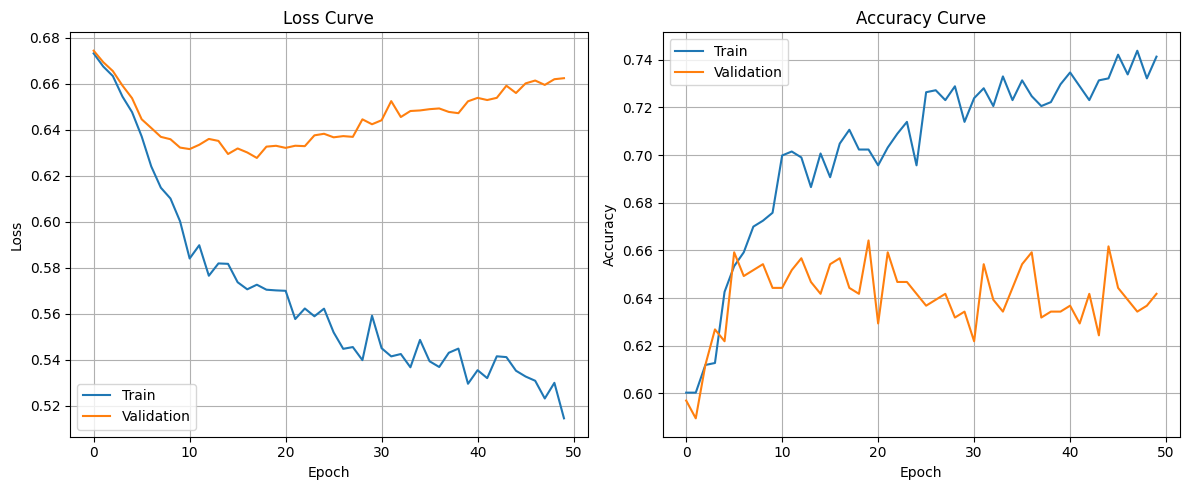

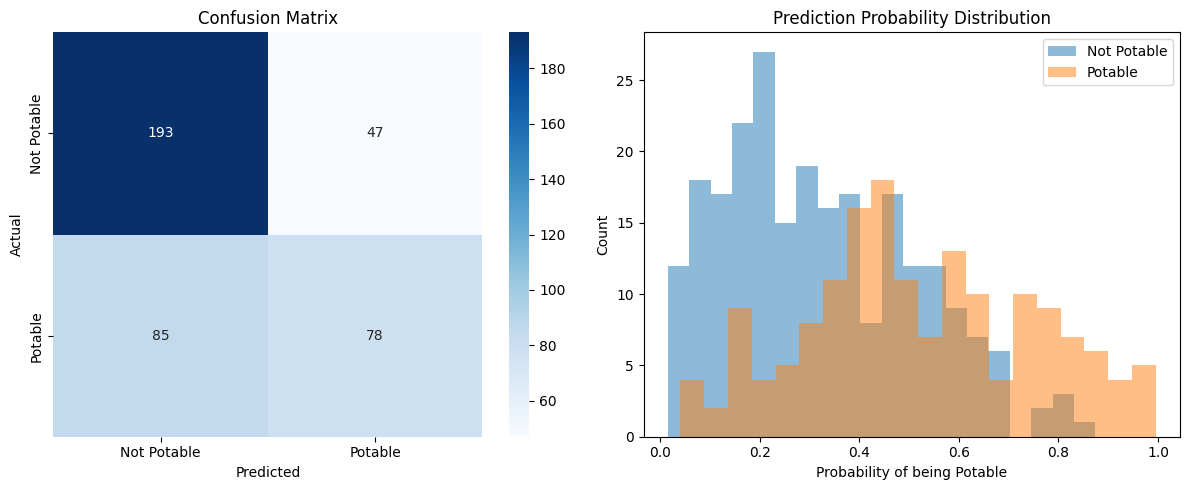


Waiting 3 seconds before starting stream processing...

STREAM PROCESSING PHASE
Starting to produce 20 messages...
Starting stream processing...

Processed 0 messages
No predictions made during stream processing.

🔬 Starting Interactive Sensor Simulation...

INTERACTIVE SENSOR SIMULATION
This simulation will prompt for sensor data every 0.1 minutes
Maximum 3 readings will be collected
Press Ctrl+C at any time to stop and view summary

🔔 Reading #1 of 3

SENSOR DATA INPUT
Please enter the current sensor readings:
(Press Ctrl+C at any time to stop)
pH level (0-14): 7.861178
Hardness (mg/L): 204.2742
Produced message 2/20
Total Dissolved Solids (ppm): 25145.02
Chloramines (ppm): 7.923315
Sulfate (mg/L): 338.2138
Conductivity (μS/cm): 469.487
Organic Carbon (ppm): 15.99341
Trihalomethanes (μg/L): 86.1673
Turbidity (NTU): 4.157657

PREDICTION RESULTS
Input Sensor Data:
  ph                  :     7.86
  Hardness            :   204.27
  Solids              : 25145.02
  Chloramines         :

KeyboardInterrupt: 

In [ ]:
# Install required packages
# !pip install confluent-kafka pandas scikit-learn torch tqdm matplotlib seaborn

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from confluent_kafka import Producer, Consumer
import json
import time
from threading import Thread
import pickle
import os

# =============================================
# 1. Data Preparation and Model Definition
# =============================================

class WaterPotabilityNN(nn.Module):
    def __init__(self):
        super(WaterPotabilityNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.model(x)

def prepare_data(csv_path):
    """Load and prepare data for training"""
    # Load and clean dataset
    data = pd.read_csv(csv_path)
    data = data.dropna()

    # Features and labels
    X = data.drop('Potability', axis=1).values
    y = data['Potability'].values

    # Normalize with Z-score
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Convert to torch tensors
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    # Split into train (60%), validation (20%), and test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler

def train_model(X_train, X_val, y_train, y_val, batch_size=32, n_epochs=50):
    """Train the neural network model"""

    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Initialize model
    model = WaterPotabilityNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Training history
    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    best_val_acc = 0
    best_model = None

    print("Starting training...\n")
    for epoch in range(n_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict()

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}: '
                  f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

    # Load best model
    model.load_state_dict(best_model)

    return model, best_model, (train_loss_history, val_loss_history, train_acc_history, val_acc_history)

def evaluate_model(model, X_test, y_test, batch_size=32):
    """Evaluate model on test set"""
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    criterion = nn.CrossEntropyLoss()
    model.eval()

    test_loss = 0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())

    test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total

    return test_loss, test_acc, all_preds, all_labels

def plot_training_history(history):
    """Plot training and validation curves"""
    train_loss_history, val_loss_history, train_acc_history, val_acc_history = history

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_loss_history, label='Train')
    plt.plot(val_loss_history, label='Validation')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_acc_history, label='Train')
    plt.plot(val_acc_history, label='Validation')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_results(all_labels, all_preds, test_probs):
    """Plot confusion matrix and prediction distributions"""
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Potable', 'Potable'],
                yticklabels=['Not Potable', 'Potable'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Prediction Probability Distribution
    plt.subplot(1, 2, 2)
    plt.hist(test_probs[np.array(all_labels) == 0], bins=20, alpha=0.5, label='Not Potable')
    plt.hist(test_probs[np.array(all_labels) == 1], bins=20, alpha=0.5, label='Potable')
    plt.title('Prediction Probability Distribution')
    plt.xlabel('Probability of being Potable')
    plt.ylabel('Count')
    plt.legend()

    plt.tight_layout()
    plt.show()

# =============================================
# 2. Stream Processing Class
# =============================================

class StreamProcessor:
    def __init__(self, model_path, scaler_path, kafka_servers='localhost:9092'):
        self.model = WaterPotabilityNN()
        self.model.load_state_dict(torch.load(model_path))
        self.model.eval()

        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)

        self.predictions = []
        self.true_labels = []
        self.probabilities = []

        # Kafka config
        self.kafka_config = {
            'bootstrap.servers': kafka_servers,
            'group.id': 'water-potability-group',
            'auto.offset.reset': 'earliest'
        }

    def preprocess(self, message):
        """Convert Kafka message to tensor"""
        try:
            data = json.loads(message)
            features = np.array([
                data['ph'],
                data['Hardness'],
                data['Solids'],
                data['Chloramines'],
                data['Sulfate'],
                data['Conductivity'],
                data['Organic_carbon'],
                data['Trihalomethanes'],
                data['Turbidity']
            ]).reshape(1, -1)

            features = self.scaler.transform(features)
            return torch.tensor(features, dtype=torch.float32)
        except Exception as e:
            print(f"Preprocessing error: {e}")
            return None

    def predict(self, message):
        """Make prediction on streaming data"""
        try:
            tensor = self.preprocess(message)
            if tensor is None:
                return None, None

            with torch.no_grad():
                output = self.model(tensor)
                proba = torch.softmax(output, dim=1)[0][1].item()
                pred = torch.argmax(output).item()
            return pred, proba
        except Exception as e:
            print(f"Prediction error: {e}")
            return None, None

    def start_consumer(self, timeout=60):
        """Start consuming from Kafka with timeout"""
        consumer = Consumer(self.kafka_config)
        consumer.subscribe(['water-quality'])

        start_time = time.time()
        message_count = 0

        try:
            while time.time() - start_time < timeout:
                msg = consumer.poll(1.0)
                if msg is None:
                    continue
                if msg.error():
                    print(f"Consumer error: {msg.error()}")
                    continue

                pred, proba = self.predict(msg.value().decode('utf-8'))
                if pred is not None:
                    data = json.loads(msg.value().decode('utf-8'))
                    if 'Potability' in data:  # If ground truth exists
                        self.true_labels.append(data['Potability'])
                    self.predictions.append(pred)
                    self.probabilities.append(proba)
                    message_count += 1

                    print(f"Message {message_count}: Prediction: {pred} (Prob: {proba:.3f}) | "
                          f"pH={data['ph']:.1f}, Hardness={data['Hardness']:.1f}")

        except KeyboardInterrupt:
            print("\nStopping consumer...")
        finally:
            consumer.close()
            print(f"\nProcessed {message_count} messages")

# =============================================
# 3. Kafka Producer (Simulates Data Stream)
# =============================================

def produce_test_messages(csv_path, num_messages=50, delay=1.0, kafka_servers='localhost:9092'):
    """Simulate streaming water quality data"""
    try:
        producer = Producer({'bootstrap.servers': kafka_servers})
        test_data = pd.read_csv(csv_path).dropna().sample(num_messages)

        print(f"Starting to produce {num_messages} messages...")

        for i, (_, row) in enumerate(test_data.iterrows()):
            message = {
                'ph': float(row['ph']),
                'Hardness': float(row['Hardness']),
                'Solids': float(row['Solids']),
                'Chloramines': float(row['Chloramines']),
                'Sulfate': float(row['Sulfate']),
                'Conductivity': float(row['Conductivity']),
                'Organic_carbon': float(row['Organic_carbon']),
                'Trihalomethanes': float(row['Trihalomethanes']),
                'Turbidity': float(row['Turbidity']),
                'Potability': int(row['Potability']),  # Include ground truth
                'timestamp': time.time(),
                'message_id': i + 1
            }
            producer.produce('water-quality', json.dumps(message))
            producer.flush()
            print(f"Produced message {i+1}/{num_messages}")
            time.sleep(delay)

        print("Finished producing messages")
    except Exception as e:
        print(f"Producer error: {e}")

# =============================================
# 4. Main Execution Functions
# =============================================

def run_batch_training(csv_path):
    """Run the complete batch training pipeline"""
    print("="*60)
    print("BATCH TRAINING PHASE")
    print("="*60)

    # Prepare data
    X_train, X_val, X_test, y_train, y_val, y_test, scaler = prepare_data(csv_path)

    # Train model
    model, best_model_state, history = train_model(X_train, X_val, y_train, y_val)

    # Save model and scaler
    torch.save(best_model_state, 'water_potability_model.pt')
    with open('scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    print(f"\nModel and scaler saved successfully!")

    # Evaluate on test set
    test_loss, test_acc, all_preds, all_labels = evaluate_model(model, X_test, y_test)

    print("\n" + "="*50)
    print("FINAL EVALUATION ON TEST SET")
    print("="*50)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Not Potable', 'Potable']))

    # Get prediction probabilities for visualization
    with torch.no_grad():
        test_probs = torch.softmax(model(X_test), dim=1)[:, 1].numpy()

    # Plot results
    plot_training_history(history)
    plot_results(all_labels, all_preds, test_probs)

    return model, scaler

def run_stream_processing(csv_path, num_messages=30, kafka_servers='localhost:9092'):
    """Run the stream processing pipeline"""
    print("\n" + "="*60)
    print("STREAM PROCESSING PHASE")
    print("="*60)

    # Check if model files exist
    if not os.path.exists('water_potability_model.pt') or not os.path.exists('scaler.pkl'):
        print("Model files not found. Please run batch training first.")
        return

    # Initialize processor
    processor = StreamProcessor('water_potability_model.pt', 'scaler.pkl', kafka_servers)

    # Start producer in background thread
    producer_thread = Thread(target=produce_test_messages,
                           args=(csv_path, num_messages, 1.0, kafka_servers))
    producer_thread.daemon = True
    producer_thread.start()

    # Give producer time to start
    time.sleep(2)

    # Start consumer
    print("Starting stream processing...")
    processor.start_consumer(timeout=num_messages + 10)  # Extra time for processing

    # Evaluate stream results
    if processor.true_labels and processor.predictions:
        print("\n" + "="*50)
        print("STREAM EVALUATION RESULTS")
        print("="*50)
        accuracy = accuracy_score(processor.true_labels, processor.predictions)
        print(f"Stream Accuracy: {accuracy*100:.2f}%")
        print("\nClassification Report:")
        print(classification_report(processor.true_labels, processor.predictions,
                                  target_names=['Not Potable', 'Potable']))
        print("\nConfusion Matrix:")
        print(confusion_matrix(processor.true_labels, processor.predictions))
    else:
        print("No predictions made during stream processing.")

# =============================================
# 5. Complete Pipeline Execution
# =============================================

def run_complete_pipeline(csv_path, stream_messages=30):
    """Run both batch training and stream processing"""
    try:
        # Phase 1: Batch Training
        model, scaler = run_batch_training(csv_path)

        # Phase 2: Stream Processing
        print("\nWaiting 3 seconds before starting stream processing...")
        time.sleep(3)
        run_stream_processing(csv_path, stream_messages)

    except Exception as e:
        print(f"Pipeline error: {e}")

# =============================================
# 6. Usage Example
# =============================================

if __name__ == "__main__":
    # Configuration
    CSV_PATH = '/content/water_potability.csv'  # Update this path
    STREAM_MESSAGES = 20  # Number of messages to process in stream

    print("Water Potability ML Pipeline")
    print("=" * 40)
    print("This pipeline will:")
    print("1. Train a neural network on water quality data")
    print("2. Simulate real-time stream processing with Kafka")
    print("3. Evaluate both batch and streaming performance")
    print("\nNote: Make sure Kafka is running on localhost:9092")
    print("=" * 40)

    # Run the complete pipeline
    run_complete_pipeline(CSV_PATH, STREAM_MESSAGES)

In [ ]:
from google.colab import auth
auth.authenticate_user()

!pip install google-cloud-storage google-cloud-bigquery google-cloud-aiplatform

import os
project_id = "1921"
os.environ['GOOGLE_CLOUD_PROJECT'] = project_id

from google.cloud import storage

client = storage.Client(project=project_id)
bucket = client.bucket('hale_dataset_bucket')

blob = bucket.blob('https://storage.googleapis.com/hale_dataset_bucket/water_potability_with_id_timestamp.csv')
blob.upload_from_filename('/content/water_potability_with_id_timestamp.csv')

blob.download_to_filename('/content/result.txt')

from google.cloud import aiplatform

aiplatform.init(project=project_id, location='us-central1')


Water Potability ML Pipeline
Available modes:
1. Training + Sensor Simulation (Recommended)
2. Complete Pipeline (Training + Kafka Stream + Sensor Simulation)
3. Training Only
4. Kafka Stream Only
5. Interactive Sensor Simulation Only
Select mode (1-5): 1

🎯 Training model once, then running sensor simulation...
Phase 1: Training the model...
BATCH TRAINING PHASE
Starting training...

Produced message 3/20
Epoch 10/50: Train Loss: 0.5911, Acc: 0.6949 | Val Loss: 0.6251, Acc: 0.6692
Epoch 20/50: Train Loss: 0.5498, Acc: 0.7239 | Val Loss: 0.6352, Acc: 0.6741
Epoch 30/50: Train Loss: 0.5496, Acc: 0.7289 | Val Loss: 0.6430, Acc: 0.6766
Epoch 40/50: Train Loss: 0.5373, Acc: 0.7214 | Val Loss: 0.6524, Acc: 0.6692
Epoch 50/50: Train Loss: 0.5216, Acc: 0.7446 | Val Loss: 0.6477, Acc: 0.6517

Model and scaler saved successfully!

FINAL EVALUATION ON TEST SET
Test Loss: 0.5858
Test Accuracy: 67.74%

Classification Report:
              precision    recall  f1-score   support

 Not Potable      

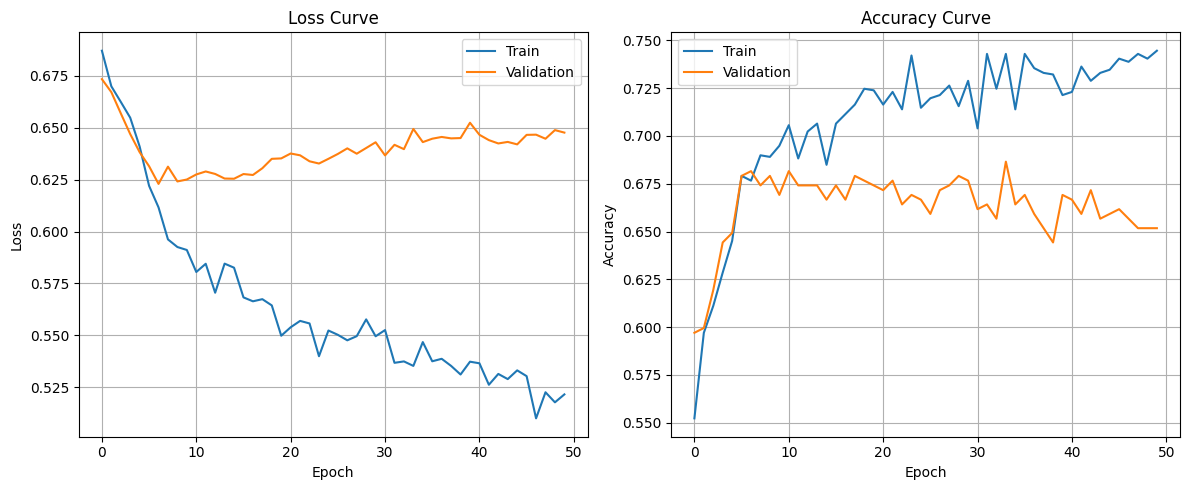

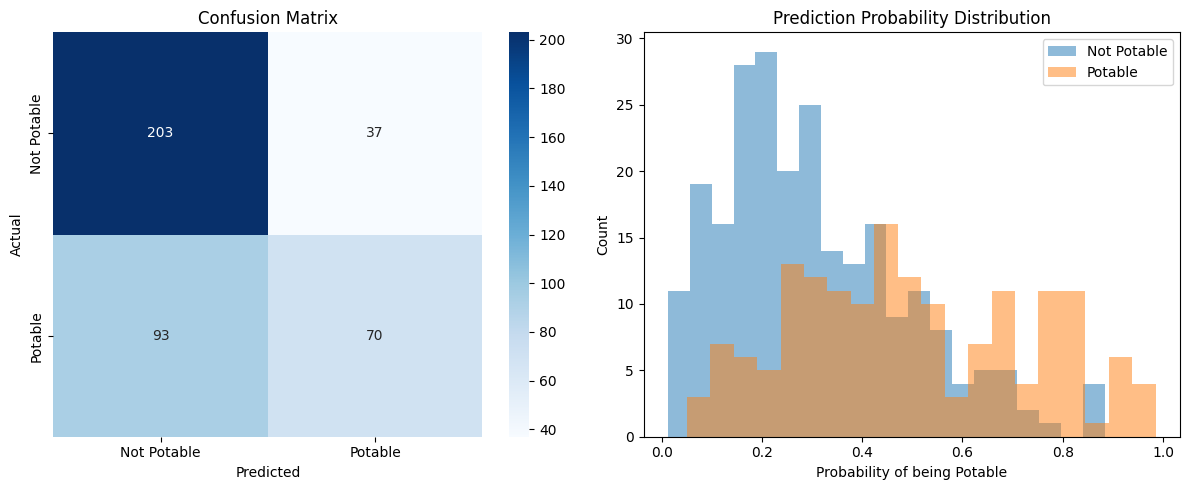


Enter interval between readings (minutes, default 5): 1
Enter number of sensor readings (default 3): 2

Phase 2: Starting sensor simulation (2 readings every 1.0 minutes)...

INTERACTIVE SENSOR SIMULATION
This simulation will prompt for sensor data every 1.0 minutes
Maximum 2 readings will be collected
Press Ctrl+C at any time to stop and view summary

🔔 Reading #1 of 2

SENSOR DATA INPUT
Please enter the current sensor readings:
(Press Ctrl+C at any time to stop)
pH level (0-14): 7.86117770099856
Hardness (mg/L): 204.274241099893
Total Dissolved Solids (ppm): 25145.0241247855
Chloramines (ppm): 4304.49248308591
Sulfate (mg/L): 3.6158905172021
Conductivity (μS/cm): 259.373321769416
Organic Carbon (ppm): 400.904349685945
Trihalomethanes (μg/L): 12.9930122359809
Turbidity (NTU): 3.4165397533412

Data Validation Warnings:
  - WARNING: Chloramines should be between 0-50 ppm (got 4304.49248308591)
  - WARNING: Organic Carbon should be between 0-50 ppm (got 400.904349685945)

Proceed with p

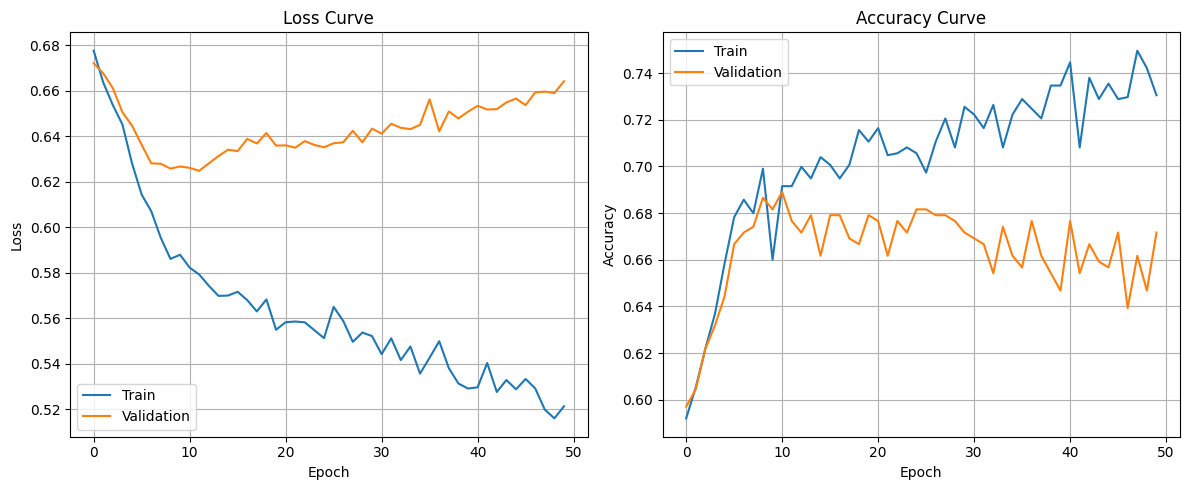

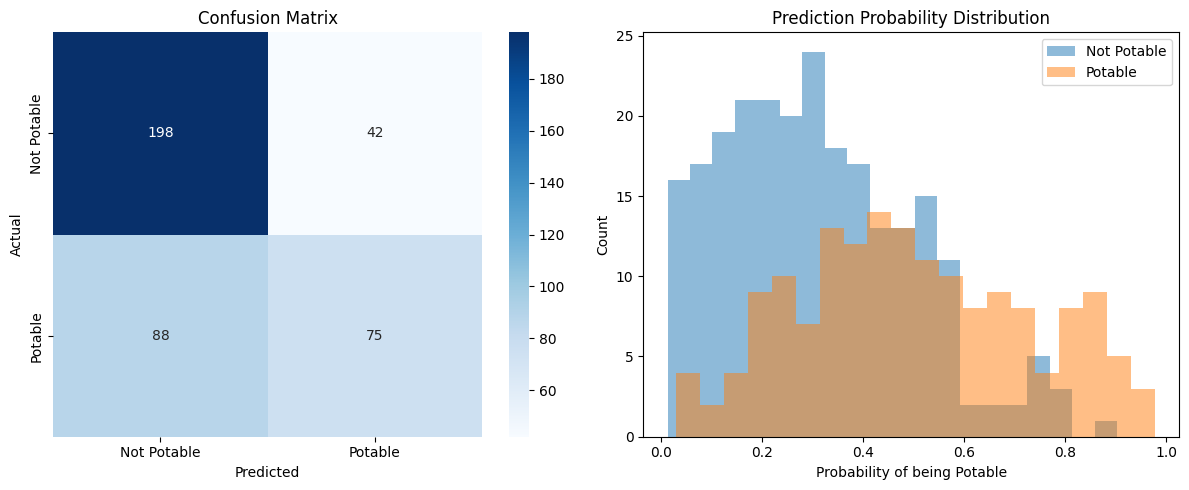


INTERACTIVE SENSOR SIMULATION
This simulation will prompt for sensor data every 5 minutes
Maximum 3 readings will be collected
Press Ctrl+C at any time to stop and view summary

🔔 Reading #1 of 3

SENSOR DATA INPUT
Please enter the current sensor readings:
(Press Ctrl+C at any time to stop)
pH level (0-14): 7.03909432108983
Produced message 4/20
Hardness (mg/L): 179.645224546271
Total Dissolved Solids (ppm): 28827.360185629
Chloramines (ppm): 4.94555519930574
Sulfate (mg/L): 389.889270941426
Conductivity (μS/cm): 593.396224520919
Organic Carbon (ppm): 12.0792071160807
Trihalomethanes (μg/L): 58.3635065409938
Turbidity (NTU): 4.36603135063288

PREDICTION RESULTS
Input Sensor Data:
  ph                  :     7.04
  Hardness            :   179.65
  Solids              : 28827.36
  Chloramines         :     4.95
  Sulfate             :   389.89
  Conductivity        :   593.40
  Organic_carbon      :    12.08
  Trihalomethanes     :    58.36
  Turbidity           :     4.37

Timestamp: 2

In [ ]:


import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from confluent_kafka import Producer, Consumer
import json
import time
from threading import Thread
import pickle
import os

# =============================================
# 1. Data Preparation and Model Definition
# =============================================

class WaterPotabilityNN(nn.Module):
    def __init__(self):
        super(WaterPotabilityNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.model(x)

def prepare_data(csv_path):
    """Load and prepare data for training"""
    # Load and clean dataset
    data = pd.read_csv(csv_path)
    data = data.dropna()

    # Features and labels
    X = data.drop('Potability', axis=1).values
    y = data['Potability'].values

    # Normalize with Z-score
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Convert to torch tensors
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    # Split into train (60%), validation (20%), and test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler

def train_model(X_train, X_val, y_train, y_val, batch_size=32, n_epochs=50):
    """Train the neural network model"""

    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Initialize model
    model = WaterPotabilityNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Training history
    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    best_val_acc = 0
    best_model = None

    print("Starting training...\n")
    for epoch in range(n_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict()

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}: '
                  f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

    # Load best model
    model.load_state_dict(best_model)

    return model, best_model, (train_loss_history, val_loss_history, train_acc_history, val_acc_history)

def evaluate_model(model, X_test, y_test, batch_size=32):
    """Evaluate model on test set"""
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    criterion = nn.CrossEntropyLoss()
    model.eval()

    test_loss = 0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())

    test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total

    return test_loss, test_acc, all_preds, all_labels

def plot_training_history(history):
    """Plot training and validation curves"""
    train_loss_history, val_loss_history, train_acc_history, val_acc_history = history

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_loss_history, label='Train')
    plt.plot(val_loss_history, label='Validation')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_acc_history, label='Train')
    plt.plot(val_acc_history, label='Validation')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_results(all_labels, all_preds, test_probs):
    """Plot confusion matrix and prediction distributions"""
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Potable', 'Potable'],
                yticklabels=['Not Potable', 'Potable'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Prediction Probability Distribution
    plt.subplot(1, 2, 2)
    plt.hist(test_probs[np.array(all_labels) == 0], bins=20, alpha=0.5, label='Not Potable')
    plt.hist(test_probs[np.array(all_labels) == 1], bins=20, alpha=0.5, label='Potable')
    plt.title('Prediction Probability Distribution')
    plt.xlabel('Probability of being Potable')
    plt.ylabel('Count')
    plt.legend()

    plt.tight_layout()
    plt.show()

# =============================================
# 2. Stream Processing Class
# =============================================

class StreamProcessor:
    def __init__(self, model_path, scaler_path, kafka_servers='localhost:9092'):
        self.model = WaterPotabilityNN()
        self.model.load_state_dict(torch.load(model_path))
        self.model.eval()

        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)

        self.predictions = []
        self.true_labels = []
        self.probabilities = []

        # Kafka config
        self.kafka_config = {
            'bootstrap.servers': kafka_servers,
            'group.id': 'water-potability-group',
            'auto.offset.reset': 'earliest'
        }

    def preprocess(self, message):
        """Convert Kafka message to tensor"""
        try:
            data = json.loads(message)
            features = np.array([
                data['ph'],
                data['Hardness'],
                data['Solids'],
                data['Chloramines'],
                data['Sulfate'],
                data['Conductivity'],
                data['Organic_carbon'],
                data['Trihalomethanes'],
                data['Turbidity']
            ]).reshape(1, -1)

            features = self.scaler.transform(features)
            return torch.tensor(features, dtype=torch.float32)
        except Exception as e:
            print(f"Preprocessing error: {e}")
            return None

    def predict(self, message):
        """Make prediction on streaming data"""
        try:
            tensor = self.preprocess(message)
            if tensor is None:
                return None, None

            with torch.no_grad():
                output = self.model(tensor)
                proba = torch.softmax(output, dim=1)[0][1].item()
                pred = torch.argmax(output).item()
            return pred, proba
        except Exception as e:
            print(f"Prediction error: {e}")
            return None, None

    def start_consumer(self, timeout=60):
        """Start consuming from Kafka with timeout"""
        consumer = Consumer(self.kafka_config)
        consumer.subscribe(['water-quality'])

        start_time = time.time()
        message_count = 0

        try:
            while time.time() - start_time < timeout:
                msg = consumer.poll(1.0)
                if msg is None:
                    continue
                if msg.error():
                    print(f"Consumer error: {msg.error()}")
                    continue

                pred, proba = self.predict(msg.value().decode('utf-8'))
                if pred is not None:
                    data = json.loads(msg.value().decode('utf-8'))
                    if 'Potability' in data:  # If ground truth exists
                        self.true_labels.append(data['Potability'])
                    self.predictions.append(pred)
                    self.probabilities.append(proba)
                    message_count += 1

                    print(f"Message {message_count}: Prediction: {pred} (Prob: {proba:.3f}) | "
                          f"pH={data['ph']:.1f}, Hardness={data['Hardness']:.1f}")

        except KeyboardInterrupt:
            print("\nStopping consumer...")
        finally:
            consumer.close()
            print(f"\nProcessed {message_count} messages")

# =============================================
# 3. Kafka Producer (Simulates Data Stream)
# =============================================

def produce_test_messages(csv_path, num_messages=50, delay=1.0, kafka_servers='localhost:9092'):
    """Simulate streaming water quality data"""
    try:
        producer = Producer({'bootstrap.servers': kafka_servers})
        test_data = pd.read_csv(csv_path).dropna().sample(num_messages)

        print(f"Starting to produce {num_messages} messages...")

        for i, (_, row) in enumerate(test_data.iterrows()):
            message = {
                'ph': float(row['ph']),
                'Hardness': float(row['Hardness']),
                'Solids': float(row['Solids']),
                'Chloramines': float(row['Chloramines']),
                'Sulfate': float(row['Sulfate']),
                'Conductivity': float(row['Conductivity']),
                'Organic_carbon': float(row['Organic_carbon']),
                'Trihalomethanes': float(row['Trihalomethanes']),
                'Turbidity': float(row['Turbidity']),
                'Potability': int(row['Potability']),  # Include ground truth
                'timestamp': time.time(),
                'message_id': i + 1
            }
            producer.produce('water-quality', json.dumps(message))
            producer.flush()
            print(f"Produced message {i+1}/{num_messages}")
            time.sleep(delay)

        print("Finished producing messages")
    except Exception as e:
        print(f"Producer error: {e}")

# =============================================
# 4. Main Execution Functions
# =============================================

def run_batch_training(csv_path):
    """Run the complete batch training pipeline"""
    print("="*60)
    print("BATCH TRAINING PHASE")
    print("="*60)

    # Prepare data
    X_train, X_val, X_test, y_train, y_val, y_test, scaler = prepare_data(csv_path)

    # Train model
    model, best_model_state, history = train_model(X_train, X_val, y_train, y_val)

    # Save model and scaler
    torch.save(best_model_state, 'water_potability_model.pt')
    with open('scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    print(f"\nModel and scaler saved successfully!")

    # Evaluate on test set
    test_loss, test_acc, all_preds, all_labels = evaluate_model(model, X_test, y_test)

    print("\n" + "="*50)
    print("FINAL EVALUATION ON TEST SET")
    print("="*50)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Not Potable', 'Potable']))

    # Get prediction probabilities for visualization
    with torch.no_grad():
        test_probs = torch.softmax(model(X_test), dim=1)[:, 1].numpy()

    # Plot results
    plot_training_history(history)
    plot_results(all_labels, all_preds, test_probs)

    return model, scaler

def run_stream_processing(csv_path, num_messages=30, kafka_servers='localhost:9092'):
    """Run the stream processing pipeline"""
    print("\n" + "="*60)
    print("STREAM PROCESSING PHASE")
    print("="*60)

    # Check if model files exist
    if not os.path.exists('water_potability_model.pt') or not os.path.exists('scaler.pkl'):
        print("Model files not found. Please run batch training first.")
        return

    # Initialize processor
    processor = StreamProcessor('water_potability_model.pt', 'scaler.pkl', kafka_servers)

    # Start producer in background thread
    producer_thread = Thread(target=produce_test_messages,
                           args=(csv_path, num_messages, 1.0, kafka_servers))
    producer_thread.daemon = True
    producer_thread.start()

    # Give producer time to start
    time.sleep(2)

    # Start consumer
    print("Starting stream processing...")
    processor.start_consumer(timeout=num_messages + 10)  # Extra time for processing

    # Evaluate stream results
    if processor.true_labels and processor.predictions:
        print("\n" + "="*50)
        print("STREAM EVALUATION RESULTS")
        print("="*50)
        accuracy = accuracy_score(processor.true_labels, processor.predictions)
        print(f"Stream Accuracy: {accuracy*100:.2f}%")
        print("\nClassification Report:")
        print(classification_report(processor.true_labels, processor.predictions,
                                  target_names=['Not Potable', 'Potable']))
        print("\nConfusion Matrix:")
        print(confusion_matrix(processor.true_labels, processor.predictions))
    else:
        print("No predictions made during stream processing.")

# =============================================
# 5. Complete Pipeline Execution
# =============================================

def run_complete_pipeline(csv_path, stream_messages=30, include_sensor_sim=False, sensor_interval=5, sensor_readings=3):
    """Run both batch training and stream processing"""
    try:
        # Phase 1: Batch Training (only once)
        model, scaler = run_batch_training(csv_path)

        # Phase 2: Stream Processing
        print("\nWaiting 3 seconds before starting stream processing...")
        time.sleep(3)
        run_stream_processing(csv_path, stream_messages)

        # Phase 3: Interactive Sensor Simulation (if requested)
        if include_sensor_sim:
            print("\nWaiting 3 seconds before starting sensor simulation...")
            time.sleep(3)
            run_sensor_simulation(interval_minutes=sensor_interval, max_readings=sensor_readings)

    except Exception as e:
        print(f"Pipeline error: {e}")

# =============================================
# 6. Interactive Sensor Simulation
# =============================================

class SensorSimulator:
    def __init__(self, model_path, scaler_path):
        self.model = WaterPotabilityNN()
        self.model.load_state_dict(torch.load(model_path))
        self.model.eval()

        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)

        self.sensor_data_history = []
        self.response_times = []

    def get_user_input(self):
        """Get sensor data from user input"""
        print("\n" + "="*60)
        print("SENSOR DATA INPUT")
        print("="*60)
        print("Please enter the current sensor readings:")
        print("(Press Ctrl+C at any time to stop)")

        try:
            sensor_data = {}

            # Get all 9 water quality parameters
            sensor_data['ph'] = float(input("pH level (0-14): "))
            sensor_data['Hardness'] = float(input("Hardness (mg/L): "))
            sensor_data['Solids'] = float(input("Total Dissolved Solids (ppm): "))
            sensor_data['Chloramines'] = float(input("Chloramines (ppm): "))
            sensor_data['Sulfate'] = float(input("Sulfate (mg/L): "))
            sensor_data['Conductivity'] = float(input("Conductivity (μS/cm): "))
            sensor_data['Organic_carbon'] = float(input("Organic Carbon (ppm): "))
            sensor_data['Trihalomethanes'] = float(input("Trihalomethanes (μg/L): "))
            sensor_data['Turbidity'] = float(input("Turbidity (NTU): "))

            return sensor_data

        except ValueError as e:
            print(f"Invalid input format: {e}")
            return None
        except KeyboardInterrupt:
            print("\nSensor simulation stopped by user.")
            return "STOP"

    def validate_sensor_data(self, data):
        """Basic validation of sensor readings"""
        validations = {
            'ph': (0, 14, "pH should be between 0-14"),
            'Hardness': (0, 1000, "Hardness should be between 0-1000 mg/L"),
            'Solids': (0, 100000, "TDS should be between 0-100000 ppm"),
            'Chloramines': (0, 50, "Chloramines should be between 0-50 ppm"),
            'Sulfate': (0, 1000, "Sulfate should be between 0-1000 mg/L"),
            'Conductivity': (0, 10000, "Conductivity should be between 0-10000 μS/cm"),
            'Organic_carbon': (0, 50, "Organic Carbon should be between 0-50 ppm"),
            'Trihalomethanes': (0, 200, "Trihalomethanes should be between 0-200 μg/L"),
            'Turbidity': (0, 100, "Turbidity should be between 0-100 NTU")
        }

        warnings = []
        for param, (min_val, max_val, msg) in validations.items():
            if param in data:
                if not (min_val <= data[param] <= max_val):
                    warnings.append(f"WARNING: {msg} (got {data[param]})")

        if warnings:
            print("\nData Validation Warnings:")
            for warning in warnings:
                print(f"  - {warning}")

            proceed = input("\nProceed with prediction anyway? (y/n): ").lower()
            return proceed == 'y'

        return True

    def predict_with_timing(self, sensor_data):
        """Make prediction and measure response time"""
        start_time = time.time()

        try:
            # Convert to numpy array
            features = np.array([
                sensor_data['ph'],
                sensor_data['Hardness'],
                sensor_data['Solids'],
                sensor_data['Chloramines'],
                sensor_data['Sulfate'],
                sensor_data['Conductivity'],
                sensor_data['Organic_carbon'],
                sensor_data['Trihalomethanes'],
                sensor_data['Turbidity']
            ]).reshape(1, -1)

            # Normalize
            features_scaled = self.scaler.transform(features)

            # Convert to tensor
            tensor = torch.tensor(features_scaled, dtype=torch.float32)

            # Make prediction
            with torch.no_grad():
                output = self.model(tensor)
                probabilities = torch.softmax(output, dim=1)[0]
                prediction = torch.argmax(output).item()
                confidence = probabilities[prediction].item()
                prob_potable = probabilities[1].item()

            end_time = time.time()
            response_time = (end_time - start_time) * 1000  # Convert to milliseconds

            return {
                'prediction': prediction,
                'confidence': confidence,
                'prob_potable': prob_potable,
                'response_time_ms': response_time,
                'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
            }

        except Exception as e:
            end_time = time.time()
            response_time = (end_time - start_time) * 1000
            print(f"Prediction error: {e}")
            return {
                'error': str(e),
                'response_time_ms': response_time,
                'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
            }

    def display_results(self, sensor_data, result):
        """Display prediction results in a formatted way"""
        print("\n" + "="*60)
        print("PREDICTION RESULTS")
        print("="*60)

        # Display input data
        print("Input Sensor Data:")
        for param, value in sensor_data.items():
            print(f"  {param:20}: {value:8.2f}")

        print(f"\nTimestamp: {result['timestamp']}")
        print(f"Response Time: {result['response_time_ms']:.2f} ms")

        if 'error' in result:
            print(f"Error: {result['error']}")
            return

        # Display prediction
        status = "POTABLE" if result['prediction'] == 1 else "NOT POTABLE"
        print(f"\nPrediction: {status}")
        print(f"Confidence: {result['confidence']*100:.1f}%")
        print(f"Potability Probability: {result['prob_potable']*100:.1f}%")

        # Risk assessment
        if result['prob_potable'] > 0.8:
            risk = "LOW RISK"
        elif result['prob_potable'] > 0.5:
            risk = "MEDIUM RISK"
        else:
            risk = "HIGH RISK"

        print(f"Risk Level: {risk}")

        # Performance metrics
        if result['response_time_ms'] < 50:
            performance = "FAST"
        elif result['response_time_ms'] < 100:
            performance = "GOOD"
        elif result['response_time_ms'] < 200:
            performance = "MEDIUM"
        else:
            performance = "SLOW"

        print(f"Response Performance: {performance}")

    def run_sensor_simulation(self, interval_minutes=5, max_readings=10):
        """Run interactive sensor simulation"""
        print("\n" + "="*80)
        print("INTERACTIVE SENSOR SIMULATION")
        print("="*80)
        print(f"This simulation will prompt for sensor data every {interval_minutes} minutes")
        print(f"Maximum {max_readings} readings will be collected")
        print("Press Ctrl+C at any time to stop and view summary")
        print("="*80)

        reading_count = 0
        start_simulation_time = time.time()

        try:
            while reading_count < max_readings:
                print(f"\n🔔 Reading #{reading_count + 1} of {max_readings}")

                # Get sensor data from user
                sensor_data = self.get_user_input()

                if sensor_data == "STOP":
                    break
                elif sensor_data is None:
                    print("Skipping this reading due to invalid input...")
                    time.sleep(5)  # Short delay before retry
                    continue

                # Validate data
                if not self.validate_sensor_data(sensor_data):
                    print("Skipping prediction due to validation concerns...")
                    time.sleep(5)
                    continue

                # Make prediction with timing
                result = self.predict_with_timing(sensor_data)

                # Store results
                reading_data = {
                    'reading_number': reading_count + 1,
                    'sensor_data': sensor_data.copy(),
                    'result': result.copy()
                }
                self.sensor_data_history.append(reading_data)
                self.response_times.append(result.get('response_time_ms', 0))

                # Display results
                self.display_results(sensor_data, result)

                reading_count += 1

                if reading_count < max_readings:
                    print(f"\n⏰ Next reading in {interval_minutes} minutes...")
                    print("(Press Ctrl+C to stop and view summary)")

                    # Wait for next interval
                    for remaining in range(interval_minutes * 60, 0, -1):
                        mins, secs = divmod(remaining, 60)
                        print(f"\rNext reading in: {mins:02d}:{secs:02d}", end="", flush=True)
                        time.sleep(1)
                    print()  # New line after countdown

        except KeyboardInterrupt:
            print("\n\nSimulation stopped by user.")

        # Display summary
        self.display_simulation_summary(start_simulation_time)

    def display_simulation_summary(self, start_time):
        """Display summary of the sensor simulation"""
        if not self.sensor_data_history:
            print("No readings were collected.")
            return

        print("\n" + "="*80)
        print("SIMULATION SUMMARY")
        print("="*80)

        total_time = time.time() - start_time
        total_readings = len(self.sensor_data_history)

        print(f"Total Duration: {total_time/60:.1f} minutes")
        print(f"Total Readings: {total_readings}")
        print(f"Average Reading Interval: {total_time/max(1, total_readings)/60:.1f} minutes")

        # Response time statistics
        if self.response_times:
            avg_response = np.mean(self.response_times)
            min_response = np.min(self.response_times)
            max_response = np.max(self.response_times)
            std_response = np.std(self.response_times)

            print(f"\nResponse Time Statistics:")
            print(f"  Average: {avg_response:.2f} ms")
            print(f"  Minimum: {min_response:.2f} ms")
            print(f"  Maximum: {max_response:.2f} ms")
            print(f"  Std Dev: {std_response:.2f} ms")

        # Prediction summary
        predictions = [reading['result'].get('prediction', -1) for reading in self.sensor_data_history]
        potable_count = predictions.count(1)
        not_potable_count = predictions.count(0)
        error_count = predictions.count(-1)

        print(f"\nPrediction Summary:")
        print(f"  Potable: {potable_count}")
        print(f"  Not Potable: {not_potable_count}")
        print(f"  Errors: {error_count}")

        if potable_count + not_potable_count > 0:
            potable_percentage = potable_count / (potable_count + not_potable_count) * 100
            print(f"  Potable Rate: {potable_percentage:.1f}%")

        # Recent readings table
        print(f"\nRecent Readings Summary:")
        print("-" * 80)
        print(f"{'#':<3} {'Timestamp':<20} {'Prediction':<12} {'Confidence':<12} {'Response (ms)':<12}")
        print("-" * 80)

        for reading in self.sensor_data_history[-5:]:  # Show last 5 readings
            num = reading['reading_number']
            timestamp = reading['result']['timestamp']

            if 'error' in reading['result']:
                pred_str = "ERROR"
                conf_str = "N/A"
            else:
                pred_str = "POTABLE" if reading['result']['prediction'] == 1 else "NOT POTABLE"
                conf_str = f"{reading['result']['confidence']*100:.1f}%"

            response_str = f"{reading['result']['response_time_ms']:.2f}"

            print(f"{num:<3} {timestamp:<20} {pred_str:<12} {conf_str:<12} {response_str:<12}")

        print("-" * 80)

def run_sensor_simulation(model_path='water_potability_model.pt', scaler_path='scaler.pkl',
                         interval_minutes=5, max_readings=5):
    """Run the interactive sensor simulation"""
    # Check if model files exist
    if not os.path.exists(model_path) or not os.path.exists(scaler_path):
        print(" Model files not found. Please run batch training first.")
        print("Required files:")
        print(f"  - {model_path}")
        print(f"  - {scaler_path}")
        return

    # Initialize and run simulation
    simulator = SensorSimulator(model_path, scaler_path)
    simulator.run_sensor_simulation(interval_minutes, max_readings)

# =============================================
# 7. Usage Example
# =============================================

if __name__ == "__main__":
    # Configuration
    CSV_PATH = '/content/water_potability_with_id_timestamp.csv'  # Update this path
    STREAM_MESSAGES = 20  # Number of messages to process in stream

    print("Water Potability ML Pipeline")
    print("=" * 60)
    print("Available modes:")
    print("1. Training + Sensor Simulation (Recommended)")
    print("2. Complete Pipeline (Training + Kafka Stream + Sensor Simulation)")
    print("3. Training Only")
    print("4. Kafka Stream Only")
    print("5. Interactive Sensor Simulation Only")
    print("=" * 60)

    try:
        mode = input("Select mode (1-5): ").strip()

        if mode == "1":
            # Training + Sensor Simulation (most common use case)
            print("\n🎯 Training model once, then running sensor simulation...")

            # Train once
            print("Phase 1: Training the model...")
            run_batch_training(CSV_PATH)

            # Get sensor simulation parameters
            try:
                interval = float(input("\nEnter interval between readings (minutes, default 5): ") or "5")
                max_readings = int(input("Enter number of sensor readings (default 3): ") or "3")
            except:
                interval, max_readings = 5, 3
                print("Using default values: 5 minutes interval, 3 readings")

            # Run sensor simulation with trained model
            print(f"\nPhase 2: Starting sensor simulation ({max_readings} readings every {interval} minutes)...")
            time.sleep(2)
            run_sensor_simulation(interval_minutes=interval, max_readings=max_readings)

        elif mode == "2":
            # Complete pipeline with everything
            print("\n Running Complete Pipeline...")
            run_complete_pipeline(CSV_PATH, STREAM_MESSAGES, include_sensor_sim=True,
                                sensor_interval=0.1, sensor_readings=3)

        elif mode == "3":
            # Training only
            print("\n🎯 Running Training Only...")
            run_batch_training(CSV_PATH)

        elif mode == "4":
            # Kafka stream only
            print("\n Running Kafka Stream Only...")
            print("Note: Make sure Kafka is running on localhost:9092")
            run_stream_processing(CSV_PATH, STREAM_MESSAGES)

        elif mode == "5":
            # Sensor simulation only (requires pre-trained model)
            print("\n Running Interactive Sensor Simulation Only...")
            try:
                interval = float(input("Enter interval between readings (minutes, default 5): ") or "5")
                max_readings = int(input("Enter number of sensor readings (default 3): ") or "3")
            except:
                interval, max_readings = 5, 3
                print("Using default values: 5 minutes interval, 3 readings")

            run_sensor_simulation(interval_minutes=interval, max_readings=max_readings)

        else:
            print("Invalid mode selected. Running Training + Sensor Simulation...")
            run_batch_training(CSV_PATH)
            time.sleep(2)
            run_sensor_simulation(interval_minutes=5, max_readings=3)

    except KeyboardInterrupt:
        print("\n👋 Pipeline stopped by user.")
    except Exception as e:
        print(f" Error: {e}")
        print("Running with Training + Sensor Simulation mode...")
        run_batch_training(CSV_PATH)
        time.sleep(2)
        run_sensor_simulation(interval_minutes=5, max_readings=3)

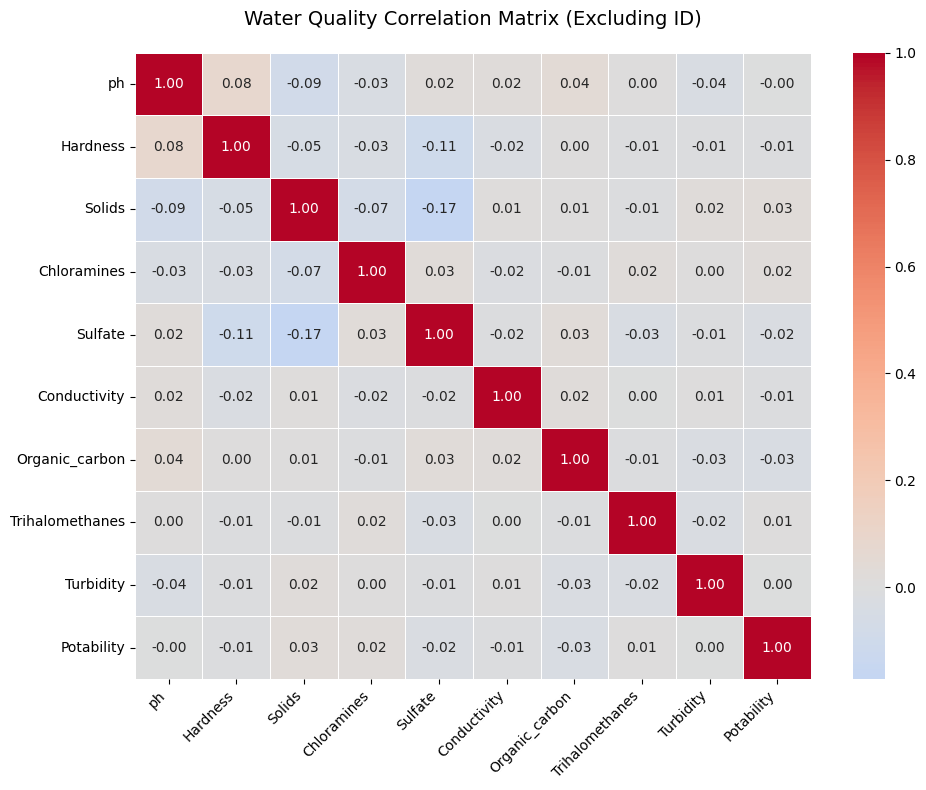

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the entire CSV file (all rows)
df = pd.read_csv('water_potability_with_id_timestamp.csv')

# Drop 'ID' column (non-numeric or irrelevant for correlation)
df_numeric = df.drop(columns=['ID'])

# Calculate correlation matrix (numeric columns only)
corr = df_numeric.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",  # 2 decimal places
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Water Quality Correlation Matrix (Excluding ID)', pad=20, fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.tight_layout()
plt.savefig('correlation_matrix_no_id.png', dpi=300, bbox_inches='tight')  # High-res save
plt.show()